In [260]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/dataset.csv")
df_clean = df.copy()


In [261]:
# remplir les valeurzs manquant de 'CREDIT_LIMIT' :

df_clean["CREDIT_LIMIT"] = df_clean["CREDIT_LIMIT"].fillna(df_clean["CREDIT_LIMIT"].median())

In [262]:
# droping column 'CUST_ID' :

df_clean = df_clean.drop(columns=["CUST_ID"])
print(df_clean.columns.tolist())


['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']


In [263]:
df_prepare_clustering = df_clean.copy()

In [264]:
log_cols = [
               "BALANCE",
               "PURCHASES",
               "ONEOFF_PURCHASES",
               "INSTALLMENTS_PURCHASES",
               "CASH_ADVANCE",
               "CREDIT_LIMIT",
               "PAYMENTS"
           ]

In [265]:
skewness_before = df_prepare_clustering[log_cols].skew()

print((skewness_before))

BALANCE                    2.393386
PURCHASES                  8.144269
ONEOFF_PURCHASES          10.045083
INSTALLMENTS_PURCHASES     7.299120
CASH_ADVANCE               5.166609
CREDIT_LIMIT               1.522636
PAYMENTS                   5.907620
dtype: float64


In [266]:
for col in log_cols:
    df_prepare_clustering[col] = np.log1p(df_prepare_clustering[col])


skewness_after = df_prepare_clustering[log_cols].skew()

print(skewness_after)

BALANCE                  -0.861021
PURCHASES                -0.764492
ONEOFF_PURCHASES          0.185854
INSTALLMENTS_PURCHASES   -0.024981
CASH_ADVANCE              0.262594
CREDIT_LIMIT             -0.101408
PAYMENTS                 -1.778312
dtype: float64


In [267]:
skew_comparison = pd.DataFrame({
    "Skewness_Before": skewness_before,
    "Skewness_After": skewness_after
})

skew_comparison["Redection"] = (skew_comparison["Skewness_Before"] - skew_comparison["Skewness_After"])

skew_comparison

,Skewness_Before,Skewness_After,Redection
BALANCE,2.393386,-0.861021,3.254407
PURCHASES,8.144269,-0.764492,8.908761
ONEOFF_PURCHASES,10.045083,0.185854,9.859229
INSTALLMENTS_PURCHASES,7.299120,-0.024981,7.324101
CASH_ADVANCE,5.166609,0.262594,4.904015
CREDIT_LIMIT,1.522636,-0.101408,1.624044
PAYMENTS,5.907620,-1.778312,7.685931


- Histogrammes + KDE Aprés Log Transformation :

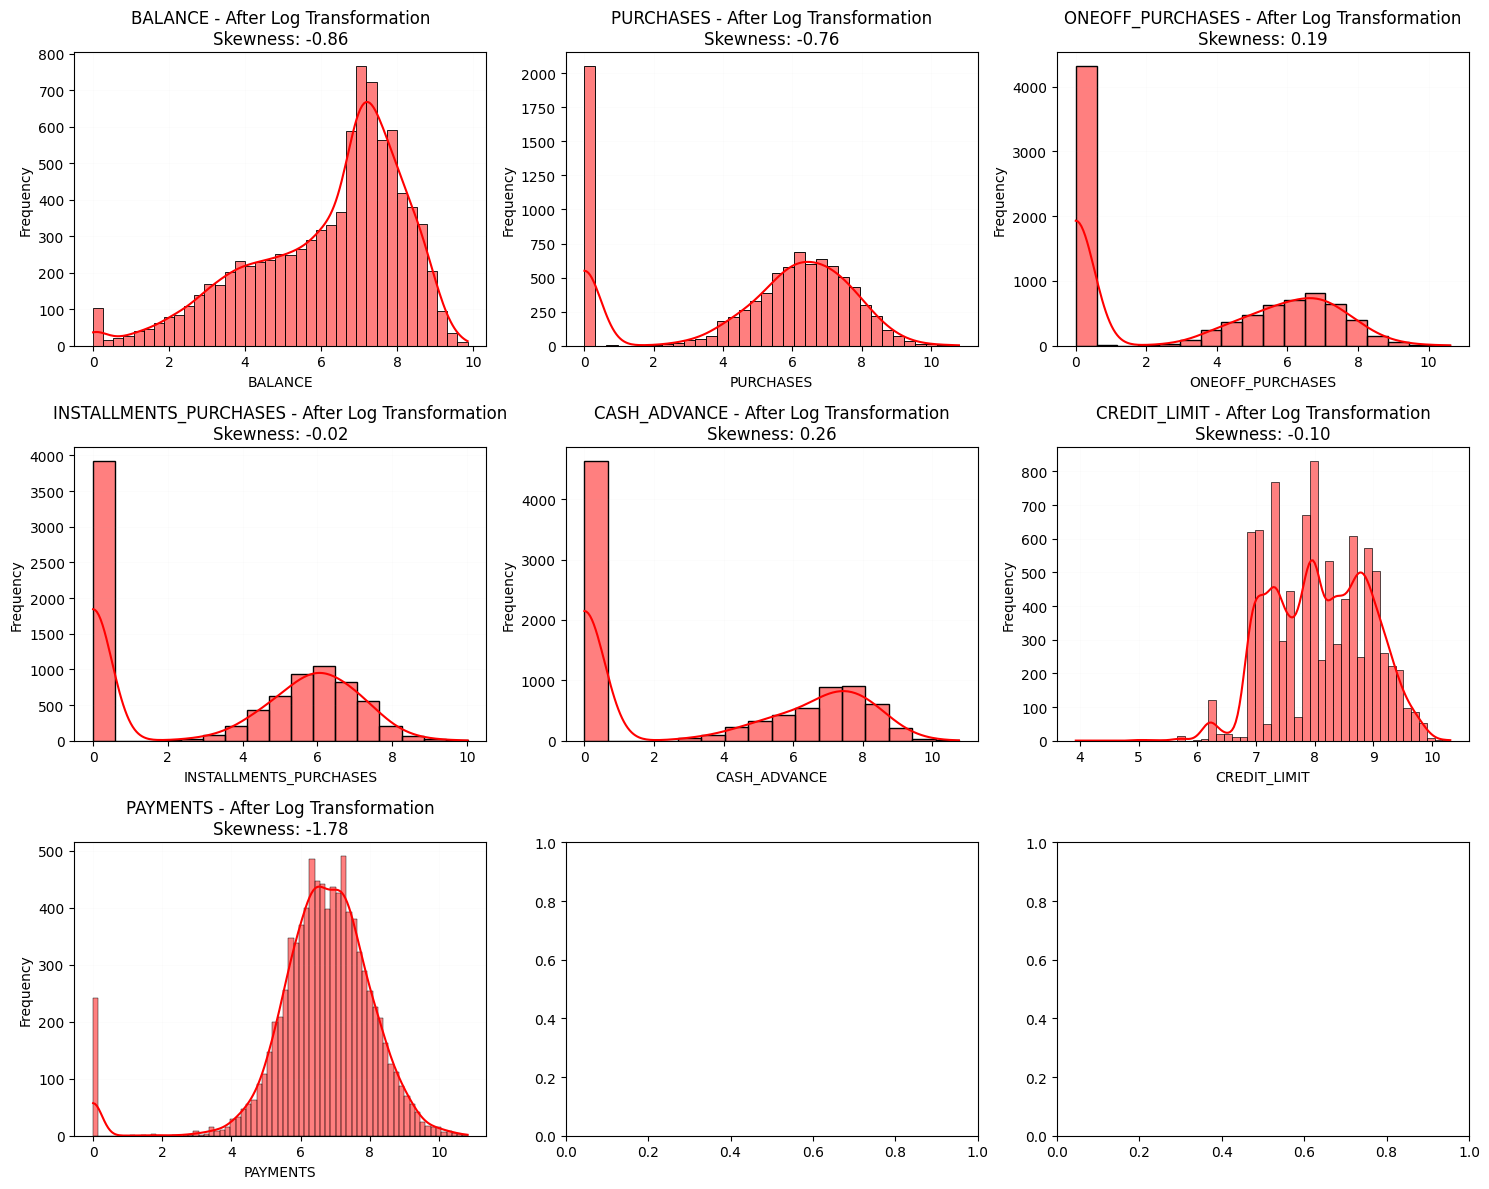

In [268]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

for index, col in enumerate(log_cols):

    row = index // 3
    col_index = index % 3

    sns.histplot(df_prepare_clustering[col],ax=ax[row, col_index],kde=True,color='red')

    ax[row, col_index].set_title(f"{col} - After Log Transformation\n"  f"Skewness: {df_prepare_clustering[col].skew():.2f}")

    ax[row, col_index].set_xlabel(col)
    ax[row, col_index].set_ylabel("Frequency")
    ax[row, col_index].grid(True, alpha=0.03)

plt.tight_layout()
plt.show()

- Standarisation :

In [269]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_prepare_clustering[log_cols])


# test
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=log_cols
)

print(X_scaled_df.mean())
print(X_scaled_df.std())

BALANCE                   1.270244e-17
PURCHASES                 6.986342e-17
ONEOFF_PURCHASES          2.540488e-17
INSTALLMENTS_PURCHASES    1.587805e-18
CASH_ADVANCE              5.716098e-17
CREDIT_LIMIT             -5.335025e-16
PAYMENTS                  3.556683e-16
dtype: float64
BALANCE                   1.000056
PURCHASES                 1.000056
ONEOFF_PURCHASES          1.000056
INSTALLMENTS_PURCHASES    1.000056
CASH_ADVANCE              1.000056
CREDIT_LIMIT              1.000056
PAYMENTS                  1.000056
dtype: float64


- PCA :

In [270]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

- Explained Variance

In [271]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.35366801 0.29256055 0.11395899 0.10007563 0.07623706 0.04969981
 0.01379994]


- Cumulative Explained Variance

In [272]:
cumulative_variance = explained_variance.cumsum()

print(cumulative_variance)

[0.35366801 0.64622856 0.76018756 0.86026318 0.93650025 0.98620006
 1.        ]


In [273]:
n_components_initial = (cumulative_variance >= 0.80).argmax() + 1

print("Nombre minimal de composantes :",n_components_initial)

Nombre minimal de composantes : 4


- Graph de PCA

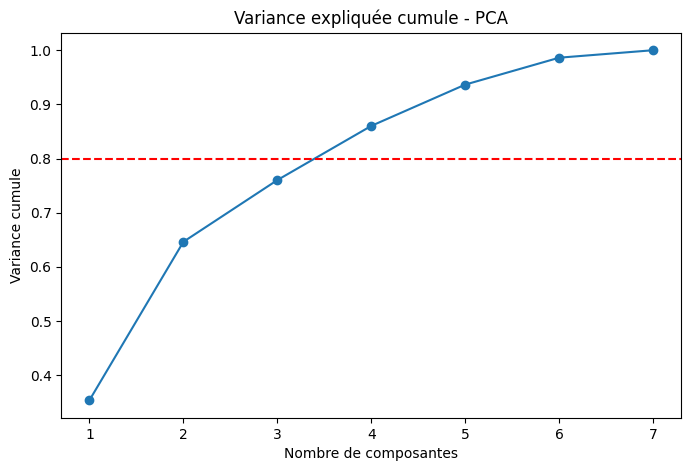

In [274]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(y=0.80,linestyle="--",color='red')

plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumule")
plt.title("Variance expliquée cumule - PCA")

plt.show()

In [275]:
# from sklearn.cluster import KMeans
# from sklearn import metrics
# from scipy.spatial.distance import cdist
# import numpy as np
# import matplotlib.pyplot as plt

In [276]:
# x1 = np.array([3, 1, 1, 2, 1, 6, 6, 6, 5, 6,
#                7, 8, 9, 8, 9, 9, 8, 4, 4, 5, 4])
# x2 = np.array([5, 4, 5, 6, 5, 8, 6, 7, 6, 7,
#                1, 2, 1, 2, 3, 2, 3, 9, 10, 9, 10])
# X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)

# plt.scatter(x1, x2, marker='o')
# plt.xlim([0, 10])
# plt.ylim([0, 10])
# plt.title('Dataset Visualization')
# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')
# plt.show()

In [277]:
# distortions = []
# inertias = []
# mapping1 = {}
# mapping2 = {}
# K = range(1, 10)

# for k in K:
#     kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)
    
#     distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])
    
#     inertias.append(kmeanModel.inertia_)
    
#     mapping1[k] = distortions[-1]
#     mapping2[k] = inertias[-1]

In [278]:
# print("Distortion values:")
# for key, val in mapping1.items():
#     print(f'{key} : {val}')

# plt.plot(K, distortions, 'bx-')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Distortion')
# plt.title('The Elbow Method using Distortion')
# plt.show()

In [279]:
# print("Inertia values:")
# for key, val in mapping2.items():
#     print(f'{key} : {val}')

# plt.plot(K, inertias, 'bx-')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Inertia')
# plt.title('The Elbow Method using Inertia')
# plt.show()

In [280]:
# k_range = range(1, 5)

# for k in k_range:
#     kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
#     y_kmeans = kmeans.fit_predict(X)
    
#     plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', marker='o', edgecolor='k', s=100)
#     plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
#                 s=300, c='red', label='Centroids', edgecolor='k')
#     plt.title(f'K-means Clustering (k={k})')
#     plt.xlabel('Feature 1')
#     plt.ylabel('Feature 2')
#     plt.legend()
#     plt.grid()
#     plt.show()

- K-means :


In [281]:
from sklearn.cluster import KMeans
from sklearn.metrics import ( silhouette_score, davies_bouldin_score, calinski_harabasz_score)

number_components_list = [2, 3, 4, 5]
k_list = range(2, 8)

results = []

for n_components in number_components_list:

    X_pca_subset = X_pca[:, :n_components]

    for k in k_list:

        kmeans = KMeans(n_clusters=k,random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_pca_subset)

        
        inertia = kmeans.inertia_

       
        silhouette = silhouette_score(X_pca_subset, labels)

        results.append({"n_components": n_components, "k": k, "inertia": inertia, "silhouette": silhouette})
        
        


In [282]:
results_df = pd.DataFrame(results)
print(results_df)


    n_components  k       inertia  silhouette
0              2  2  23546.231773    0.430922
1              2  3  13250.771262    0.448719
2              2  4  10420.610260    0.422778
3              2  5   8247.578818    0.410069
4              2  6   6687.617382    0.394525
5              2  7   5637.302350    0.398414
6              3  2  30684.841554    0.367888
7              3  3  20211.664628    0.382580
8              3  4  16455.107516    0.388720
9              3  5  13787.086186    0.390832
10             3  6  11705.472554    0.398600
11             3  7  10315.462020    0.346692
12             4  2  36950.204557    0.324170
13             4  3  26451.431141    0.333879
14             4  4  22520.481077    0.326674
15             4  5  19746.574088    0.326618
16             4  6  17412.565490    0.328030
17             4  7  15582.255201    0.304555
18             5  2  41715.842010    0.304574
19             5  3  31186.456003    0.309408
20             5  4  27093.013216 

In [283]:
best_silhouette = results_df.loc[
    results_df["silhouette"].idxmax()
]

print(best_silhouette)

n_components        2.000000
k                   3.000000
inertia         13250.771262
silhouette          0.448719
Name: 1, dtype: float64


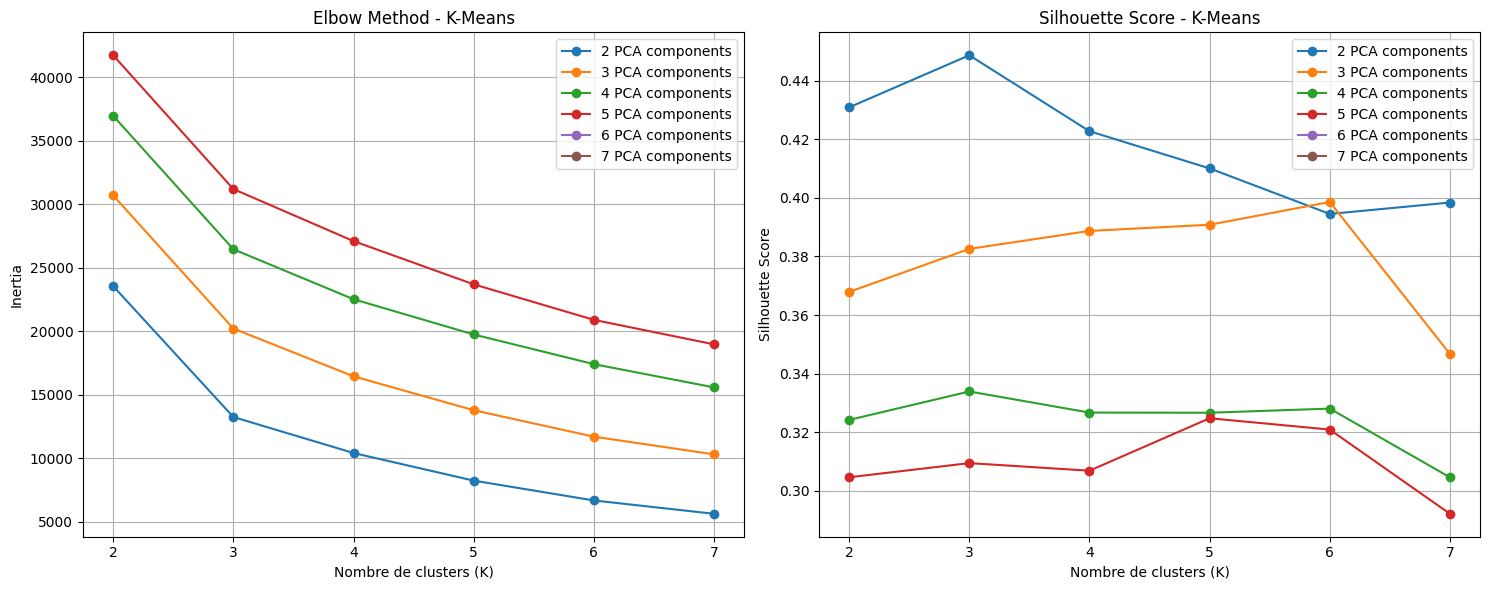

In [284]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Elbow Method

for n_components in k_list:

    subset = results_df[
        results_df["n_components"] == n_components
    ]

    ax[0].plot( subset["k"], subset["inertia"], marker="o", label=f"{n_components} PCA components"  )

ax[0].set_xlabel("Nombre de clusters (K)")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow Method - K-Means")
ax[0].legend()
ax[0].grid(True)

# Silhouette Score

for n_components in k_list:

    subset = results_df[ results_df["n_components"] == n_components ]

    ax[1].plot( subset["k"], subset["silhouette"], marker="o", label=f"{n_components} PCA components")

ax[1].set_xlabel("Nombre de clusters (K)")
ax[1].set_ylabel("Silhouette Score")
ax[1].set_title("Silhouette Score - K-Means")
ax[1].legend()
ax[1].grid(True)


plt.tight_layout()
plt.show()

- heatmap components  (x) K et silhouette.

In [285]:
silhouette_matrix = results_df.pivot( index="n_components",  columns="k",  values="silhouette")

- Heatmap :

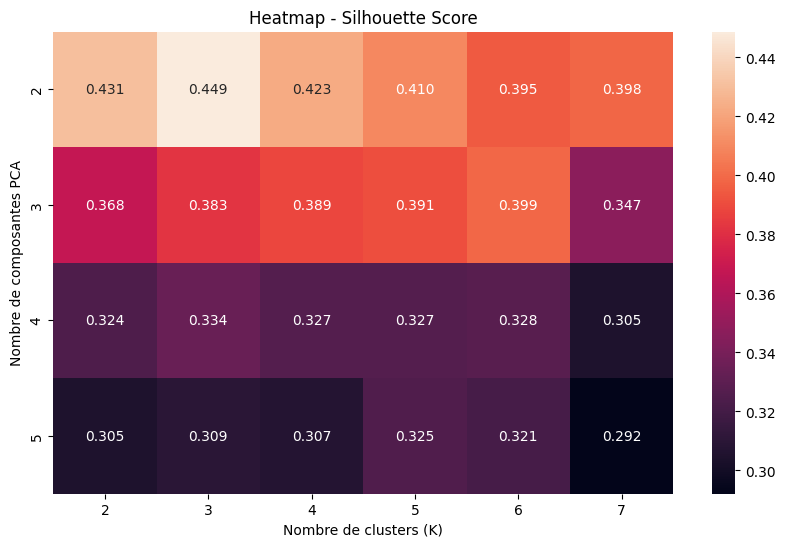

In [286]:
plt.figure(figsize=(10, 6))

sns.heatmap( silhouette_matrix, annot=True, fmt=".3f")

plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Nombre de composantes PCA")
plt.title("Heatmap - Silhouette Score")
plt.show()

- Cluster balance

In [287]:
n_components = 3
k = 3

X_selected = X_pca[:, :n_components]

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_selected)

In [288]:
cluster_counts = pd.Series(labels).value_counts(
    normalize=True
) * 100

print(cluster_counts.sort_index())

0    26.726257
1    39.899441
2    33.374302
Name: proportion, dtype: float64


- DBSCAN :

In [289]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

X_pca_current = X_pca[:, :3]

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan


,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.5
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None


In [290]:
# en va voir nombre des clusters :
labels_dbscan = dbscan.fit_predict(X_pca_current)
labels_dbscan
print("nombre des clusters :",len(set(labels_dbscan)))

nombre des clusters : 4


In [301]:
# pour les valeurs egaux -1 se sont pas des clusters :
n_clusters = print("nombre des clusters sans des noises(-1) :",len(set(labels_dbscan) - {-1}))
n_clusters = len(set(labels_dbscan) - {-1})


nombre des clusters sans des noises(-1) : 3


In [292]:
#  en calcule porcentage de Noise % :
noise_mask = labels_dbscan == -1
noise_percentage = noise_mask.mean() * 100
noise_percentage

np.float64(0.5251396648044693)

In [ ]:
#  Calculons Silhouette sans les points bruits :

mask = labels_dbscan != -1
X_no_noise = X_pca_current[mask]
labels_no_noise = labels_dbscan[mask]

silhouette = silhouette_score( X_no_noise, labels_no_noise)
silhouette

0.2393358011457969

In [303]:
if n_clusters >= 2:

    X_no_noise = X_pca_current[mask]
    labels_no_noise = labels[mask]

    silhouette = silhouette_score( X_no_noise,  labels_no_noise )

    davies_bouldin = davies_bouldin_score( X_no_noise,  labels_no_noise  )

    calinski_harabasz = calinski_harabasz_score( X_no_noise,  labels_no_noise )

else:

    silhouette = np.nan
    davies_bouldin = np.nan
    calinski_harabasz = np.nan

In [ ]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
min_samples_values = [3, 5, 7, 10]

In [306]:
dbscan_results = []

for eps in eps_values:

    for min_samples in min_samples_values:

        dbscan = DBSCAN(eps=eps, min_samples=min_samples)

        labels = dbscan.fit_predict(X_pca_current)

        n_clusters = len(set(labels) - {-1})

        noise_percentage = ((labels == -1).mean() * 100)

        mask = labels != -1

        if n_clusters >= 2:

            X_no_noise = X_pca_current[mask]
            labels_no_noise = labels[mask]

            silhouette = silhouette_score( X_no_noise, labels_no_noise )

        else:
            silhouette = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "nombre_clusters": n_clusters,
            "silhouette": silhouette,
            "davies_bouldin": davies_bouldin,
            "calinski_harabasz": calinski_harabasz,
            "noise_percentage": noise_percentage
        })

In [308]:
# converter results par DataFrame :
dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df = pd.DataFrame( dbscan_results )
dbscan_results_df

,eps,min_samples,nombre_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_percentage
0,0.2,3,81,-0.315527,1.001511,6102.278778,8.603352
1,0.2,5,36,-0.193008,1.001511,6102.278778,13.888268
2,0.2,7,26,-0.038819,1.001511,6102.278778,19.664804
3,0.2,10,30,0.163357,1.001511,6102.278778,28.949721
4,0.3,3,23,-0.030569,1.001511,6102.278778,2.268156
5,0.3,5,15,-0.036651,1.001511,6102.278778,3.575419
6,0.3,7,9,0.060644,1.001511,6102.278778,5.195531
7,0.3,10,8,-0.038053,1.001511,6102.278778,7.541899
8,0.4,3,9,-0.063556,1.001511,6102.278778,0.737430
9,0.4,5,8,0.214090,1.001511,6102.278778,1.206704


- Comparaison entre k-means et DBSCAN :

In [309]:
n_components = 3
k = 3

X_selected = X_pca[:, :n_components]

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_selected)

silhouette_kmeans = silhouette_score(
    X_selected,
    labels_kmeans
)

davies_bouldin_kmeans = davies_bouldin_score(
    X_selected,
    labels_kmeans
)

calinski_harabasz_kmeans = calinski_harabasz_score(
    X_selected,
    labels_kmeans
)


In [311]:
dbscan_results_df

,eps,min_samples,nombre_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_percentage
0,0.2,3,81,-0.315527,1.001511,6102.278778,8.603352
1,0.2,5,36,-0.193008,1.001511,6102.278778,13.888268
2,0.2,7,26,-0.038819,1.001511,6102.278778,19.664804
3,0.2,10,30,0.163357,1.001511,6102.278778,28.949721
4,0.3,3,23,-0.030569,1.001511,6102.278778,2.268156
5,0.3,5,15,-0.036651,1.001511,6102.278778,3.575419
6,0.3,7,9,0.060644,1.001511,6102.278778,5.195531
7,0.3,10,8,-0.038053,1.001511,6102.278778,7.541899
8,0.4,3,9,-0.063556,1.001511,6102.278778,0.737430
9,0.4,5,8,0.214090,1.001511,6102.278778,1.206704


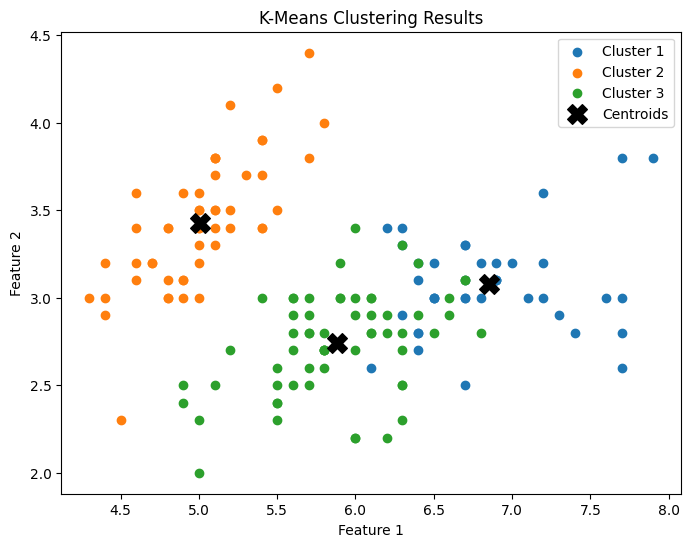

In [ ]:
# # exepmle :
# from sklearn.datasets import load_iris
# from sklearn.cluster import KMeans
# from sklearn.metrics import davies_bouldin_score
# import matplotlib.pyplot as plt

# # Load the Iris dataset
# iris = load_iris()
# data = iris.data

# # Perform K-Means clustering
# kmeans = KMeans(n_clusters=3)
# kmeans.fit(data)

# # Get the cluster labels
# labels = kmeans.labels_

# # Calculate Davies-Bouldin Index
# db_index = davies_bouldin_score(data, labels)
# # print(f&quot;Davies-Bouldin Index: {db_index}&quot;)

# # Plot the clustering results in a scatter plot
# plt.figure(figsize=(8, 6))

# # Extract the centroids of each cluster
# centroids = kmeans.cluster_centers_

# # Scatter plot the data points with different colors for each cluster
# for i in range(3):
#     cluster_data = data[labels == i]
#     plt.scatter(cluster_data[:, 0], cluster_data[:, 1], label=f'Cluster {i + 1}')

# # Plot the centroids as well
# plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='k', marker='X', label='Centroids')

# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')
# plt.title('K-Means Clustering Results')
# plt.legend()
# plt.show()